# PhyloCartoPlot Workflow - Step-by-Step Walkthrough

This notebook walks through the complete pipeline for creating phylogeographic visualizations.

**PhyloCartoPlot:** Combines phylogenetic trees, geographic distributions, and trait data into publication-ready visualizations.

**Pipeline:**
1. Format geographic coordinate data
2. Add trait/metadata values to coordinates
3. Build phylogenetic tree from sequences
4. Create tree + map visualization

## Setup

Configure paths and imports for the workflow.

In [21]:
import os
import sys
from pathlib import Path

# In Jupyter, use current working directory and search for workflow markers
def find_workflow_dir():
    """Find workflow_dir by looking for the input and scripts folders"""
    current = Path.cwd()
    
    # First check current directory
    if (current / 'input').exists() and (current / 'scripts').exists():
        return current
    
    # Check parent
    if (current.parent / 'input').exists() and (current.parent / 'scripts').exists():
        return current.parent
    
    # Check grandparent
    if (current.parent.parent / 'input').exists() and (current.parent.parent / 'scripts').exists():
        return current.parent.parent
    
    # If not found, raise error
    raise FileNotFoundError("Could not find workflow directory with 'input' and 'scripts' folders")

workflow_dir = find_workflow_dir()

# Construct paths
input_dir = workflow_dir / 'input'
output_dir = workflow_dir / 'output'
preprocessing_dir = workflow_dir / 'scripts' / 'preprocessing'
visualization_dir = workflow_dir / 'scripts' / 'visualization'

# Add ONLY preprocessing to path
sys.path.insert(0, str(preprocessing_dir))

print("Workflow Configuration")
print("="*70)
print(f"Workflow:        {workflow_dir}")
print(f"Preprocessing:   {preprocessing_dir}")
print(f"Visualization:   {visualization_dir}")
print(f"Input:           {input_dir}")
print(f"Output:          {output_dir}")
print("="*70)
print("\n✓ Paths configured")

Workflow Configuration
Workflow:        c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\workflow
Preprocessing:   c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\workflow\scripts\preprocessing
Visualization:   c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\workflow\scripts\visualization
Input:           c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\workflow\input
Output:          c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\workflow\output

✓ Paths configured


## Step 1: Format Geographic Coordinates

Takes raw geographic coordinate data and maps specimens to phylogenetic node names.

In [22]:
from format_gbif_data import format_gbif

print("\n" + "="*70)
print("STEP 1: Format Geographic Coordinate Data")
print("="*70)

gbif_file = input_dir / 'gbif_coffea_ex3.csv'
nodes_file = input_dir / 'node_names.csv'

print(f"\nInput files:")
print(f"  ├─ Geographic coordinates: {gbif_file.name}")
print(f"  └─ Node name mapping:      {nodes_file.name}")

# Call with absolute paths (DON'T CHANGE WORKING DIRECTORY)
format_gbif(str(gbif_file), str(nodes_file))

print(f"\n✓ Step 1 complete")


STEP 1: Format Geographic Coordinate Data

Input files:
  ├─ Geographic coordinates: gbif_coffea_ex3.csv
  └─ Node name mapping:      node_names.csv
Data saved to c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\workflow\input\gbif_coffea_ex3_formatted.csv

✓ Step 1 complete


## Step 2: Add Trait/Metadata Values

Merge formatted geographic data with trait or metadata values.

**Note:** Metadata file must have a `trait_value` column (can be any trait: caffeine, elevation, rainfall, phenotype, etc.)

In [25]:
from add_metadata import add_metadata

print("\n" + "="*70)
print("STEP 2: Add Trait/Metadata Values")
print("="*70)

formatted_file = input_dir / 'gbif_coffea_ex3_formatted.csv'
metadata_file = input_dir / 'no_caffeine_nodes_w_specimen.csv'

print(f"\nInput files:")
print(f"  ├─ Formatted coordinates: {formatted_file.name}")
print(f"  └─ Metadata (trait_value): {metadata_file.name}")

# Change to preprocessing directory
os.chdir(preprocessing_dir)

# Call add_metadata
add_metadata(str(formatted_file), str(metadata_file))

# Change back
os.chdir(workflow_dir / 'docs')

print(f"\n✓ Step 2 complete")


STEP 2: Add Trait/Metadata Values

Input files:
  ├─ Formatted coordinates: gbif_coffea_ex3_formatted.csv
  └─ Metadata (trait_value): no_caffeine_nodes_w_specimen.csv
Data saved to: c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\workflow\input\gbif_coffea_ex3_w_metadata.csv

✓ Step 2 complete


## Step 3: Build Phylogenetic Tree

Build phylogenetic tree from aligned DNA sequences using neighbor-joining method.


STEP 3: Build Phylogenetic Tree

Input file:
  └─ Aligned sequences: aligned_caffeine_without_nodes_w_no_coords.fasta

Method: Neighbor-joining with identity distance metric


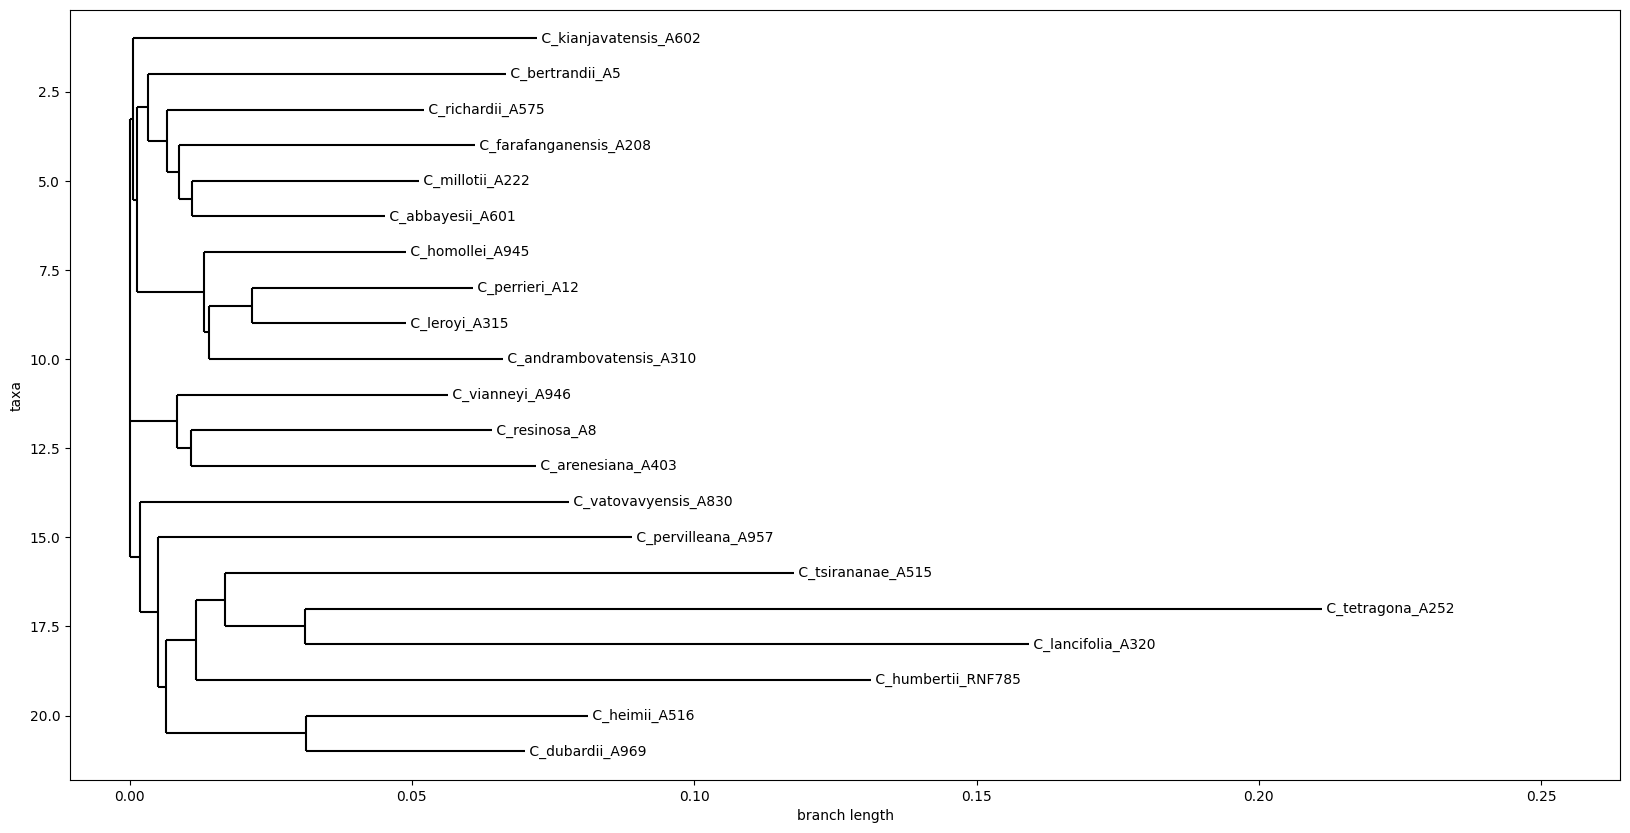


✓ Step 3 complete


In [28]:
from build_phylogenetic_tree import build_tree

print("\n" + "="*70)
print("STEP 3: Build Phylogenetic Tree")
print("="*70)

fasta_file = input_dir / 'aligned_caffeine_without_nodes_w_no_coords.fasta'

print(f"\nInput file:")
print(f"  └─ Aligned sequences: {fasta_file.name}")
print(f"\nMethod: Neighbor-joining with identity distance metric")

# Change to preprocessing directory
os.chdir(preprocessing_dir)

# Call build_tree
build_tree(str(fasta_file))

# Change back
os.chdir(workflow_dir / 'docs')

print(f"\n✓ Step 3 complete")

## Step 4: Create Phylogeographic Visualization

Create the final tree + map visualization with unified trait coloring.

This step requires running `tree_to_map.py` from the command line (not automated in notebook).

In [32]:
print("\n" + "="*70)
print("STEP 4: Create Phylogeographic Visualization")
print("="*70)

# Files generated in previous steps
tree_file = input_dir / 'aligned_caffeine_without_nodes_w_no_coords_tree.nwk'
gps_metadata_file = input_dir / 'coords_w_caff_wout_no_caff_nodes.csv'
offsets_file = input_dir / 'offsets_caff.csv'

print(f"\nInput files (from previous steps):")
print(f"  ├─ Tree:            {tree_file.name}")
print(f"  ├─ GPS + Metadata:  {gps_metadata_file.name}")
print(f"  └─ Node offsets:    {offsets_file.name}")

# Check if files exist
files_exist = tree_file.exists() and gps_metadata_file.exists() and offsets_file.exists()

if files_exist:
    print(f"\n✓ All input files found")
    print(f"\nTo create the visualization, run from command line:")
    print(f"\n  cd {visualization_dir}")
    print(f"  python tree_to_map.py \\")
    print(f"      --nwk {tree_file} \\")
    print(f"      --gps {gps_metadata_file} \\")
    print(f"      --offset {offsets_file}")
    print(f"\nOutput will be saved to: ../output/")
    print(f"  ├─ tree2map.svg (vector format)")
    print(f"  └─ tree2map.png (raster format)")
else:
    print(f"\n⚠ Warning: Some input files not found")
    if not tree_file.exists():
        print(f"  ✗ {tree_file.name}")
    if not gps_metadata_file.exists():
        print(f"  ✗ {gps_metadata_file.name}")
    if not offsets_file.exists():
        print(f"  ✗ {offsets_file.name}")
    print(f"\nMake sure Steps 1-3 completed successfully")


STEP 4: Create Phylogeographic Visualization

Input files (from previous steps):
  ├─ Tree:            aligned_caffeine_without_nodes_w_no_coords_tree.nwk
  ├─ GPS + Metadata:  coords_w_caff_wout_no_caff_nodes.csv
  └─ Node offsets:    offsets_caff.csv

✓ All input files found

To create the visualization, run from command line:

  cd c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\workflow\scripts\visualization
  python tree_to_map.py \
      --nwk c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\workflow\input\aligned_caffeine_without_nodes_w_no_coords_tree.nwk \
      --gps c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\workflow\input\coords_w_caff_wout_no_caff_nodes.csv \
      --offset c:\Users\adm1\OneDrive - USherbrooke\Documents\memoire\phylocartoplot\workflow\input\offsets_caff.csv

Output will be saved to: ../output/
  ├─ tree2map.svg (vector format)
  └─ tree2map.png (raster format)


## Summary & Data Inspection

Overview of generated files and data quality.

In [4]:
import pandas as pd

print("\n" + "="*70)
print("PREPROCESSING SUMMARY")
print("="*70)

# Check what files were created
print(f"\nGenerated files in input/ directory:")
print(f"{'Filename':<45} {'Size':>12}")
print("-" * 60)
for f in sorted(input_dir.glob('*')):
    if f.is_file():
        size = f.stat().st_size
        if size > 1024*1024:
            size_str = f"{size/(1024*1024):.1f} MB"
        elif size > 1024:
            size_str = f"{size/1024:.1f} KB"
        else:
            size_str = f"{size} B"
        print(f"{f.name:<45} {size_str:>12}")

# Show summary of key generated files
print(f"\n" + "="*70)
print("DATA INSPECTION")
print("="*70)

formatted_file = input_dir / 'coords_w_caff_formatted.csv'
if formatted_file.exists():
    df = pd.read_csv(formatted_file)
    print(f"\n1. Formatted Coordinates ({formatted_file.name}):")
    print(f"   Records: {len(df)}")
    print(f"   Columns: {', '.join(df.columns)}")
    print(f"\n   Sample data:")
    print(df.head(3).to_string(index=False))

metadata_file = input_dir / 'coords_w_caff_w_metadata.csv'
if metadata_file.exists():
    df = pd.read_csv(metadata_file)
    print(f"\n2. Geographic Data + Metadata ({metadata_file.name}):")
    print(f"   Records: {len(df)}")
    print(f"   Columns: {', '.join(df.columns)}")
    if 'trait_value' in df.columns:
        print(f"   Trait value range: {df['trait_value'].min():.4f} - {df['trait_value'].max():.4f}")
    print(f"\n   Sample data:")
    print(df.head(3).to_string(index=False))

tree_file = input_dir / 'aligned_caffeine_tree.nwk'
if tree_file.exists():
    print(f"\n3. Phylogenetic Tree ({tree_file.name}):")
    with open(tree_file) as f:
        tree_content = f.read()
    print(f"   Status: ✓ Generated")
    print(f"   Size: {len(tree_content)} characters")
    print(f"   Format: Newick")

print(f"\n" + "="*70)
print("NEXT STEP")
print("="*70)
print(f"\nRun tree_to_map.py to create the phylogeographic visualization")
print(f"\nCommand:")
print(f"  cd scripts/visualization")
print(f"  python tree_to_map.py \\")
print(f"      --nwk ../../input/aligned_caffeine_tree.nwk \\")
print(f"      --gps ../../input/coords_w_caff_w_metadata.csv \\")
print(f"      --offset ../../input/offsets_caff.csv")
print(f"\n" + "="*70)


PREPROCESSING SUMMARY

Generated files in input/ directory:
Filename                                              Size
------------------------------------------------------------
aligned_caffeine.fasta                            727.1 KB
aligned_caffeine_tree.nwk                           1.0 KB
aligned_caffeine_without_nodes_w_no_coords.fasta     610.7 KB
aligned_caffeine_without_nodes_w_no_coords_tree.nwk        854 B
coords_w_caff.csv                                  18.5 KB
coords_w_caff_wout_no_caff_nodes.csv               18.2 KB
gbif_coffea_ex3.csv                                31.6 KB
gbif_coffea_ex3_formatted.csv                       3.2 KB
gbif_coffea_ex3_w_caffeine.csv                        44 B
madaclim_enviro.tif                                 5.3 MB
no_caffeine_nodes_w_specimen.csv                     621 B
node_names.csv                                       913 B
offsets_caff.csv                                    1.2 KB

DATA INSPECTION

3. Phylogenetic Tree (ali

## Workflow Complete

The preprocessing pipeline has generated:

**Data Files:**
- `coords_w_caff_formatted.csv` - Formatted geographic coordinates
- `coords_w_caff_w_metadata.csv` - Coordinates with trait/metadata values
- `aligned_caffeine_tree.nwk` - Phylogenetic tree in Newick format

**Next:** Run `tree_to_map.py` to create the final visualization with:
- Phylogenetic tree (left panel) colored by trait values
- Geographic map (right panel) with colored occurrence points
- Connection lines linking tree nodes to geographic locations

The tool is generic and works with:
- Any species or taxa
- Any geographic region
- Any trait or metadata (just ensure column is named `trait_value`)
- Any raster or base map